In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize
import emcee
import corner
from IPython.display import display, Math

In [3]:
df = pd.read_csv('../all_times_combined.csv')
t = df['t'].to_numpy()
epoch = df['Epoch'].to_numpy()
upper_err = df['Upper Error'].to_numpy()
lower_err = df['Lower Error'].to_numpy()
uncertainty = np.mean([upper_err, lower_err], axis=0)

In [4]:
# this method for separating literature/Nickel/TESS observations
# only works because these epochs were *not* observed multiple times
start_nickel = np.where(epoch==634)[0][0]
start_tess = np.where(epoch==-68)[0][0]

period_true = 1.4079405
t0_true = 2458779.37508
f_true_tess = 0.01
f_true_other = 0.01

In [5]:
epoch -= 302 # to match quadratic fit

In [6]:
tess_mask = np.concatenate([np.zeros(68, dtype=bool), np.ones(348, dtype=bool)])

In [7]:
def log_likelihood(theta, x, y, yerr):
    period, t0, log_f_tess, log_f_other = theta
    model = (period * x) + t0
    sigma2 = yerr**2
    sigma2[tess_mask] += model[tess_mask]**2 * np.exp(2 * log_f_tess)
    sigma2[~tess_mask] += model[~tess_mask]**2 * np.exp(2 * log_f_other)
    return -0.5 * np.sum((y - model) ** 2 / sigma2 + np.log(sigma2))

nll = lambda *args: -log_likelihood(*args)
initial = np.array([period_true, t0_true, np.log(f_true_tess), np.log(f_true_other)])
soln = minimize(nll, initial, args=(epoch, t, uncertainty))
period_ml, t0_ml, log_f_tess_ml, log_f_other_ml = soln.x

print("Maximum likelihood estimates:")
print("P = {0:.3f}".format(period_ml))
print("t0 = {0:.3f}".format(t0_ml))
print("f (TESS) = {0:.3f}".format(np.exp(log_f_tess_ml)))
print("f (other) = {0:.3f}".format(np.exp(log_f_other_ml)))

Maximum likelihood estimates:
P = 1.408
t0 = 2459204.573
f (TESS) = 0.000
f (other) = 0.000


In [8]:
def log_prior(theta):
    period, t0, log_f_tess, log_f_other = theta
    if -5.0 < period < 5.0 and t0_true-10000 < t0 < t0_true+10000 and -30.0 < log_f_tess < 5.0 and -30.0 < log_f_other < 5.0:
        return 0.0
    return -np.inf

def log_probability(theta, x, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)

In [9]:
pos = soln.x + 1e-4 * np.random.randn(128, 4)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(epoch, t, uncertainty)
)
sampler.run_mcmc(pos, 50000, progress=True);

100%|██████████| 50000/50000 [01:46<00:00, 468.07it/s]


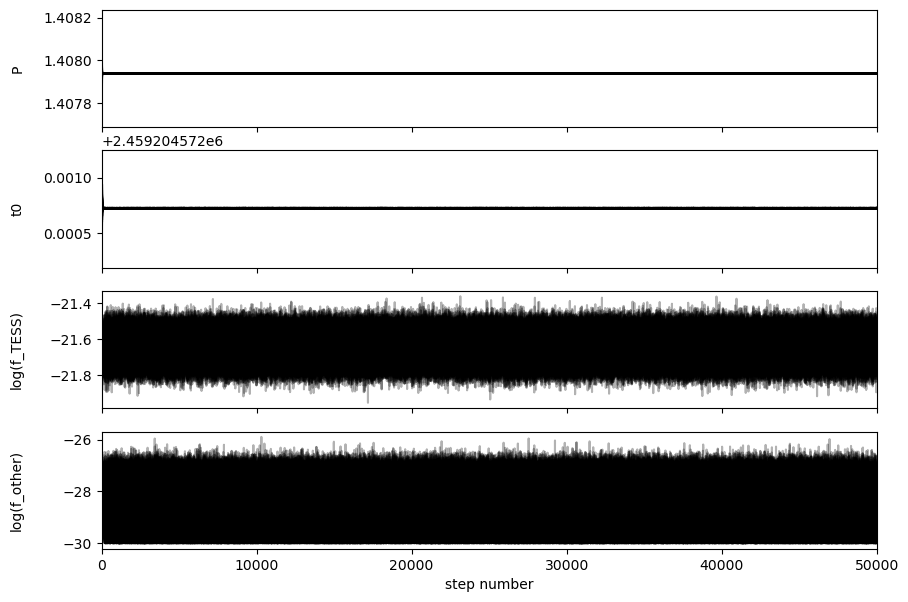

In [10]:
fig, axes = plt.subplots(4, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["P", "t0", "log(f_TESS)", "log(f_other)"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

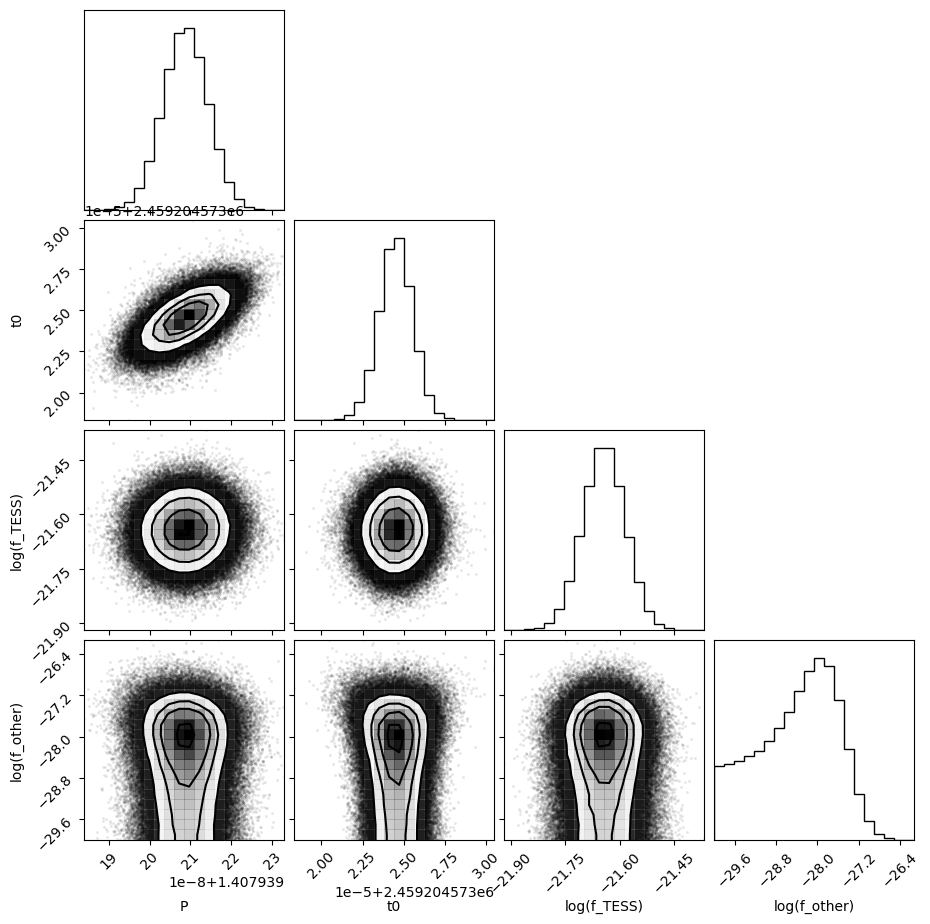

In [11]:
flat_samples = sampler.get_chain(discard=15000, thin=15, flat=True)

fig = corner.corner(
    flat_samples, labels=labels, truths=[period_true, t0_true, np.log(f_true_tess), np.log(f_true_other)]
);

In [12]:
for i in range(ndim):
    mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.10f}_{{-{1:.10f}}}^{{{2:.10f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], labels[i])
    display(Math(txt))

<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
/var/folders/sr/g5sjm4bd55nbc1x4wnqb1dqw0000gn/T/ipykernel_79216/2703471813.py:4: SyntaxWarning: invalid escape sequence '\m'
  txt = "\mathrm{{{3}}} = {0:.10f}_{{-{1:.10f}}}^{{{2:.10f}}}"


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [13]:
best_P = np.median(flat_samples[:, 0])
best_t0 = np.median(flat_samples[:, 1])

trend = (best_P * epoch) + best_t0

In [14]:
epoch += 302

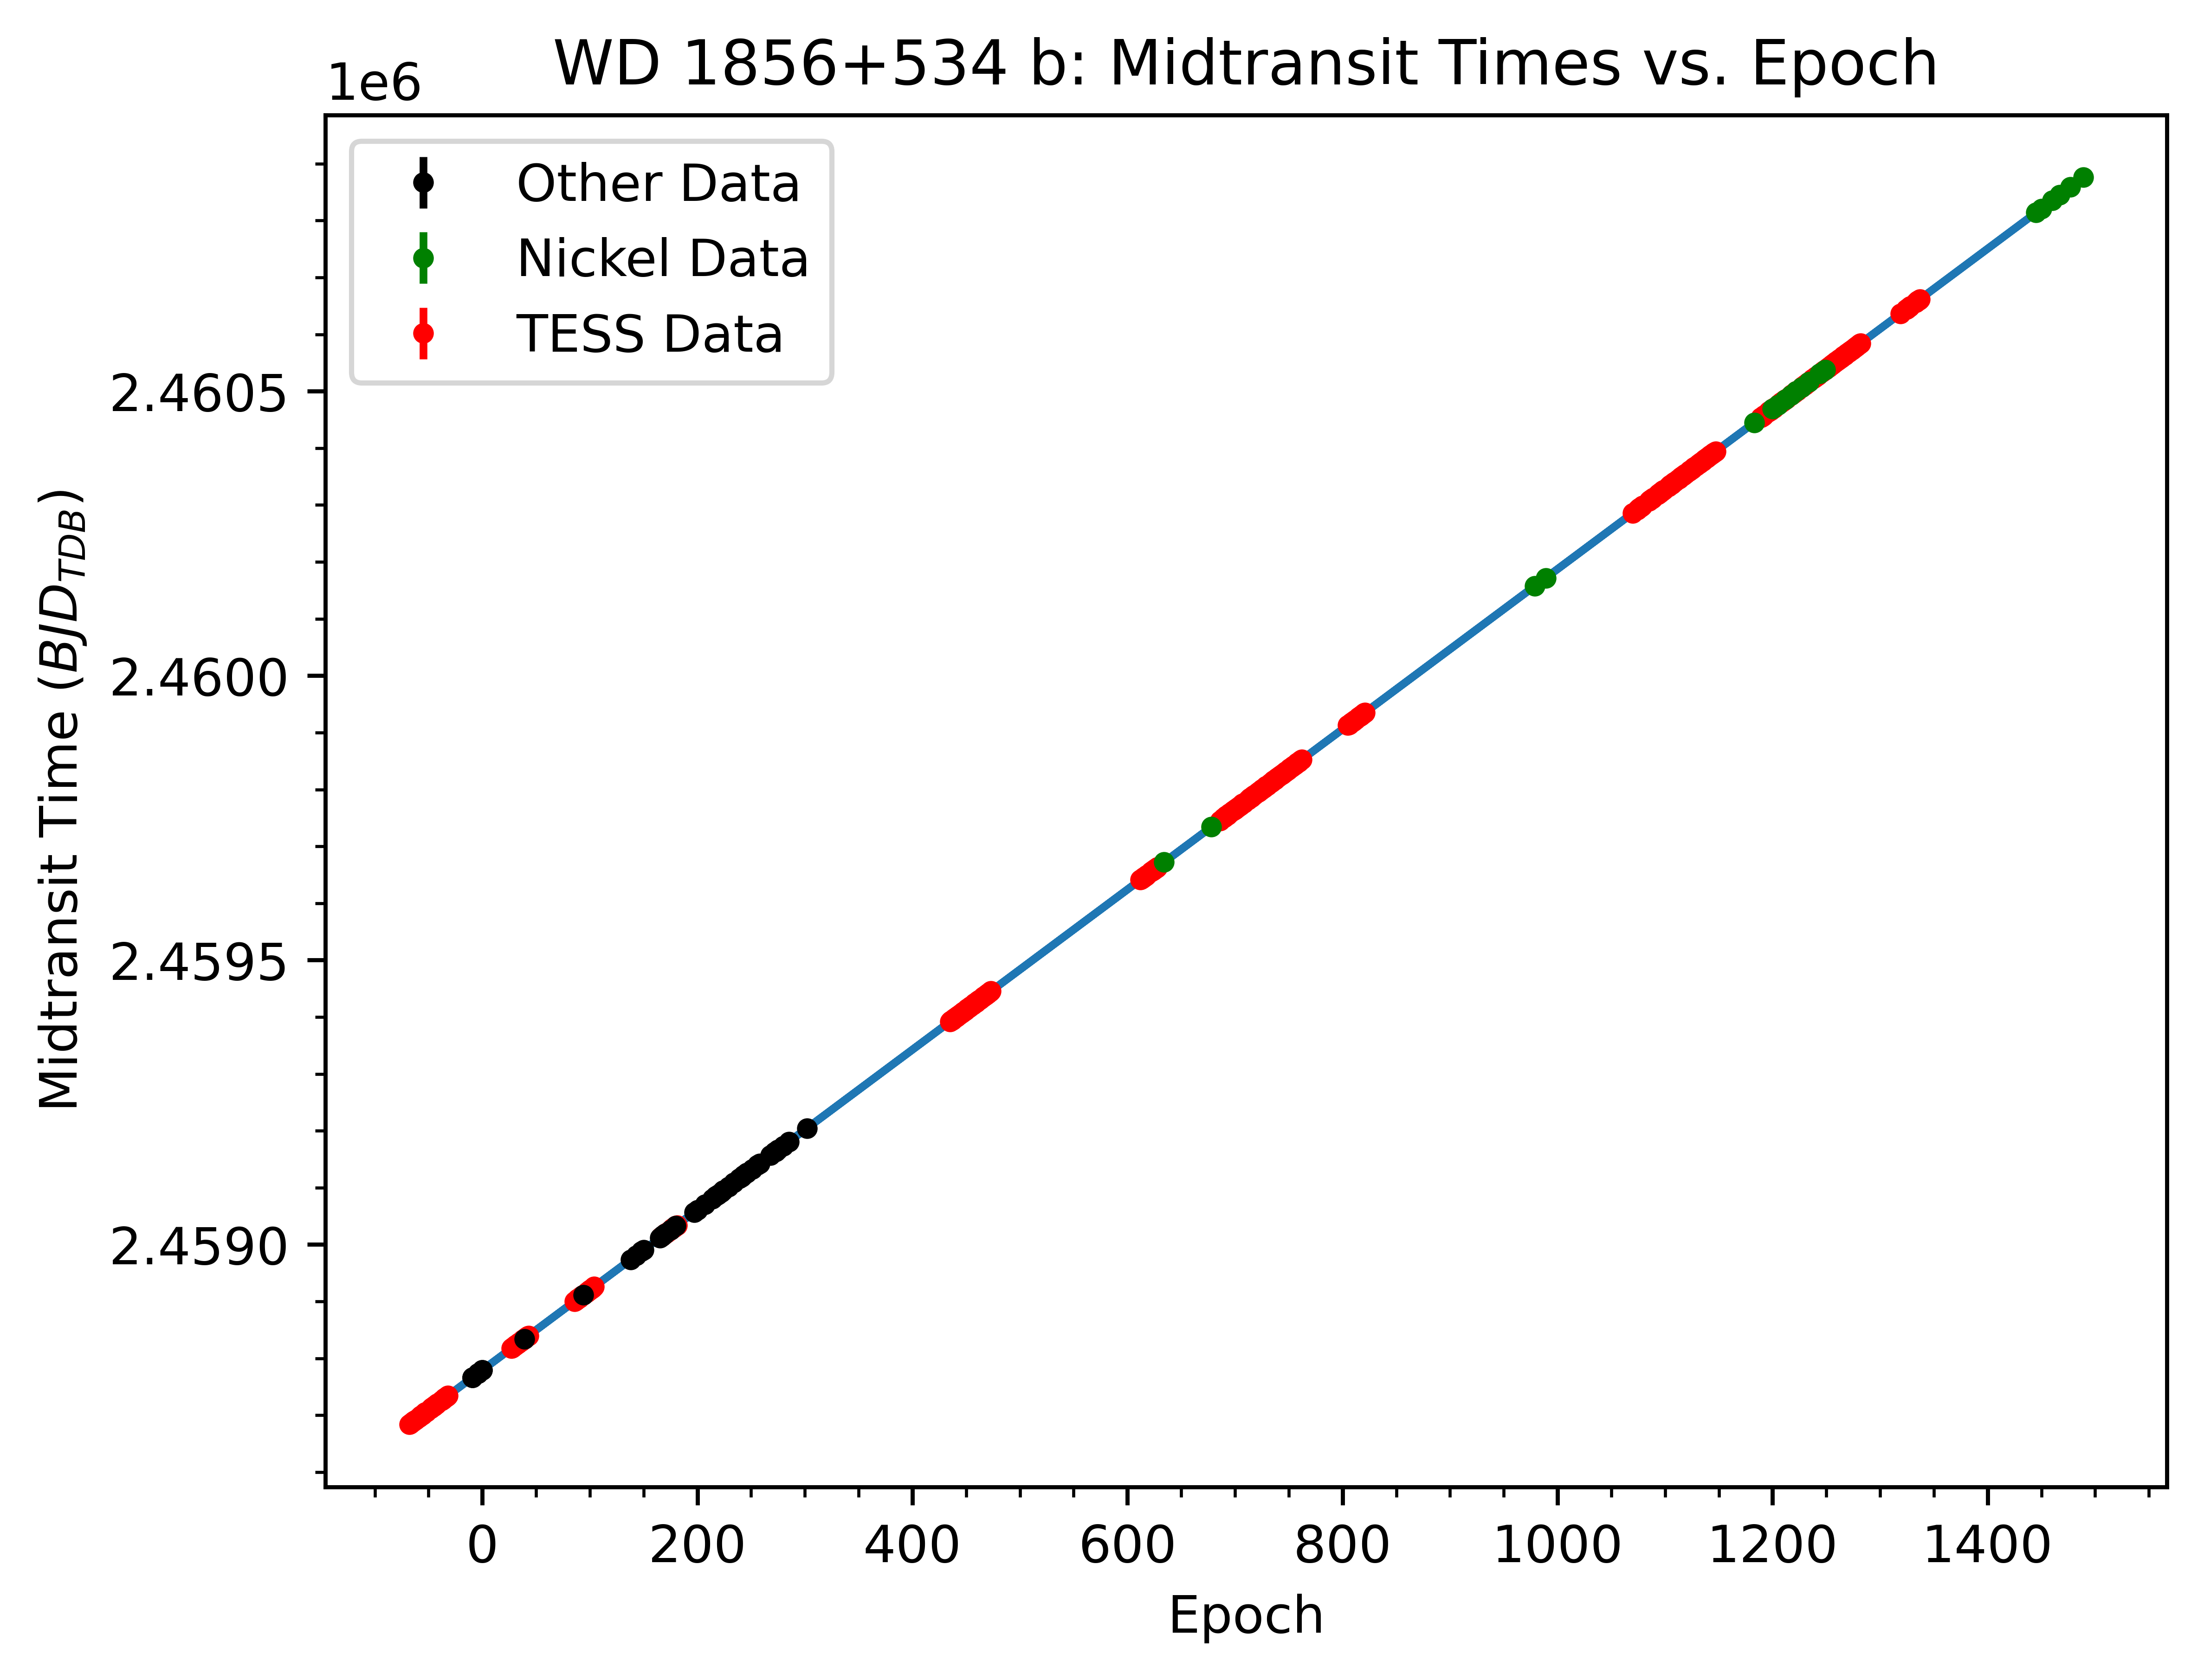

In [15]:
fig, ax = plt.subplots(dpi = 800)
plt.errorbar(epoch[:start_nickel],t[:start_nickel],yerr=uncertainty[:start_nickel],fmt='k.',label='Other Data',zorder=3)
plt.errorbar(epoch[start_nickel:start_tess],t[start_nickel:start_tess],yerr=uncertainty[start_nickel:start_tess],fmt='g.',label='Nickel Data',zorder=3)
plt.errorbar(epoch[start_tess:],t[start_tess:],yerr=uncertainty[start_tess:],fmt='r.',label='TESS Data',zorder=2)
plt.plot(epoch,trend, zorder=1)
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Midtransit Time $(BJD_{TDB})$')
plt.title('WD 1856+534 b: Midtransit Times vs. Epoch')
ax.minorticks_on()

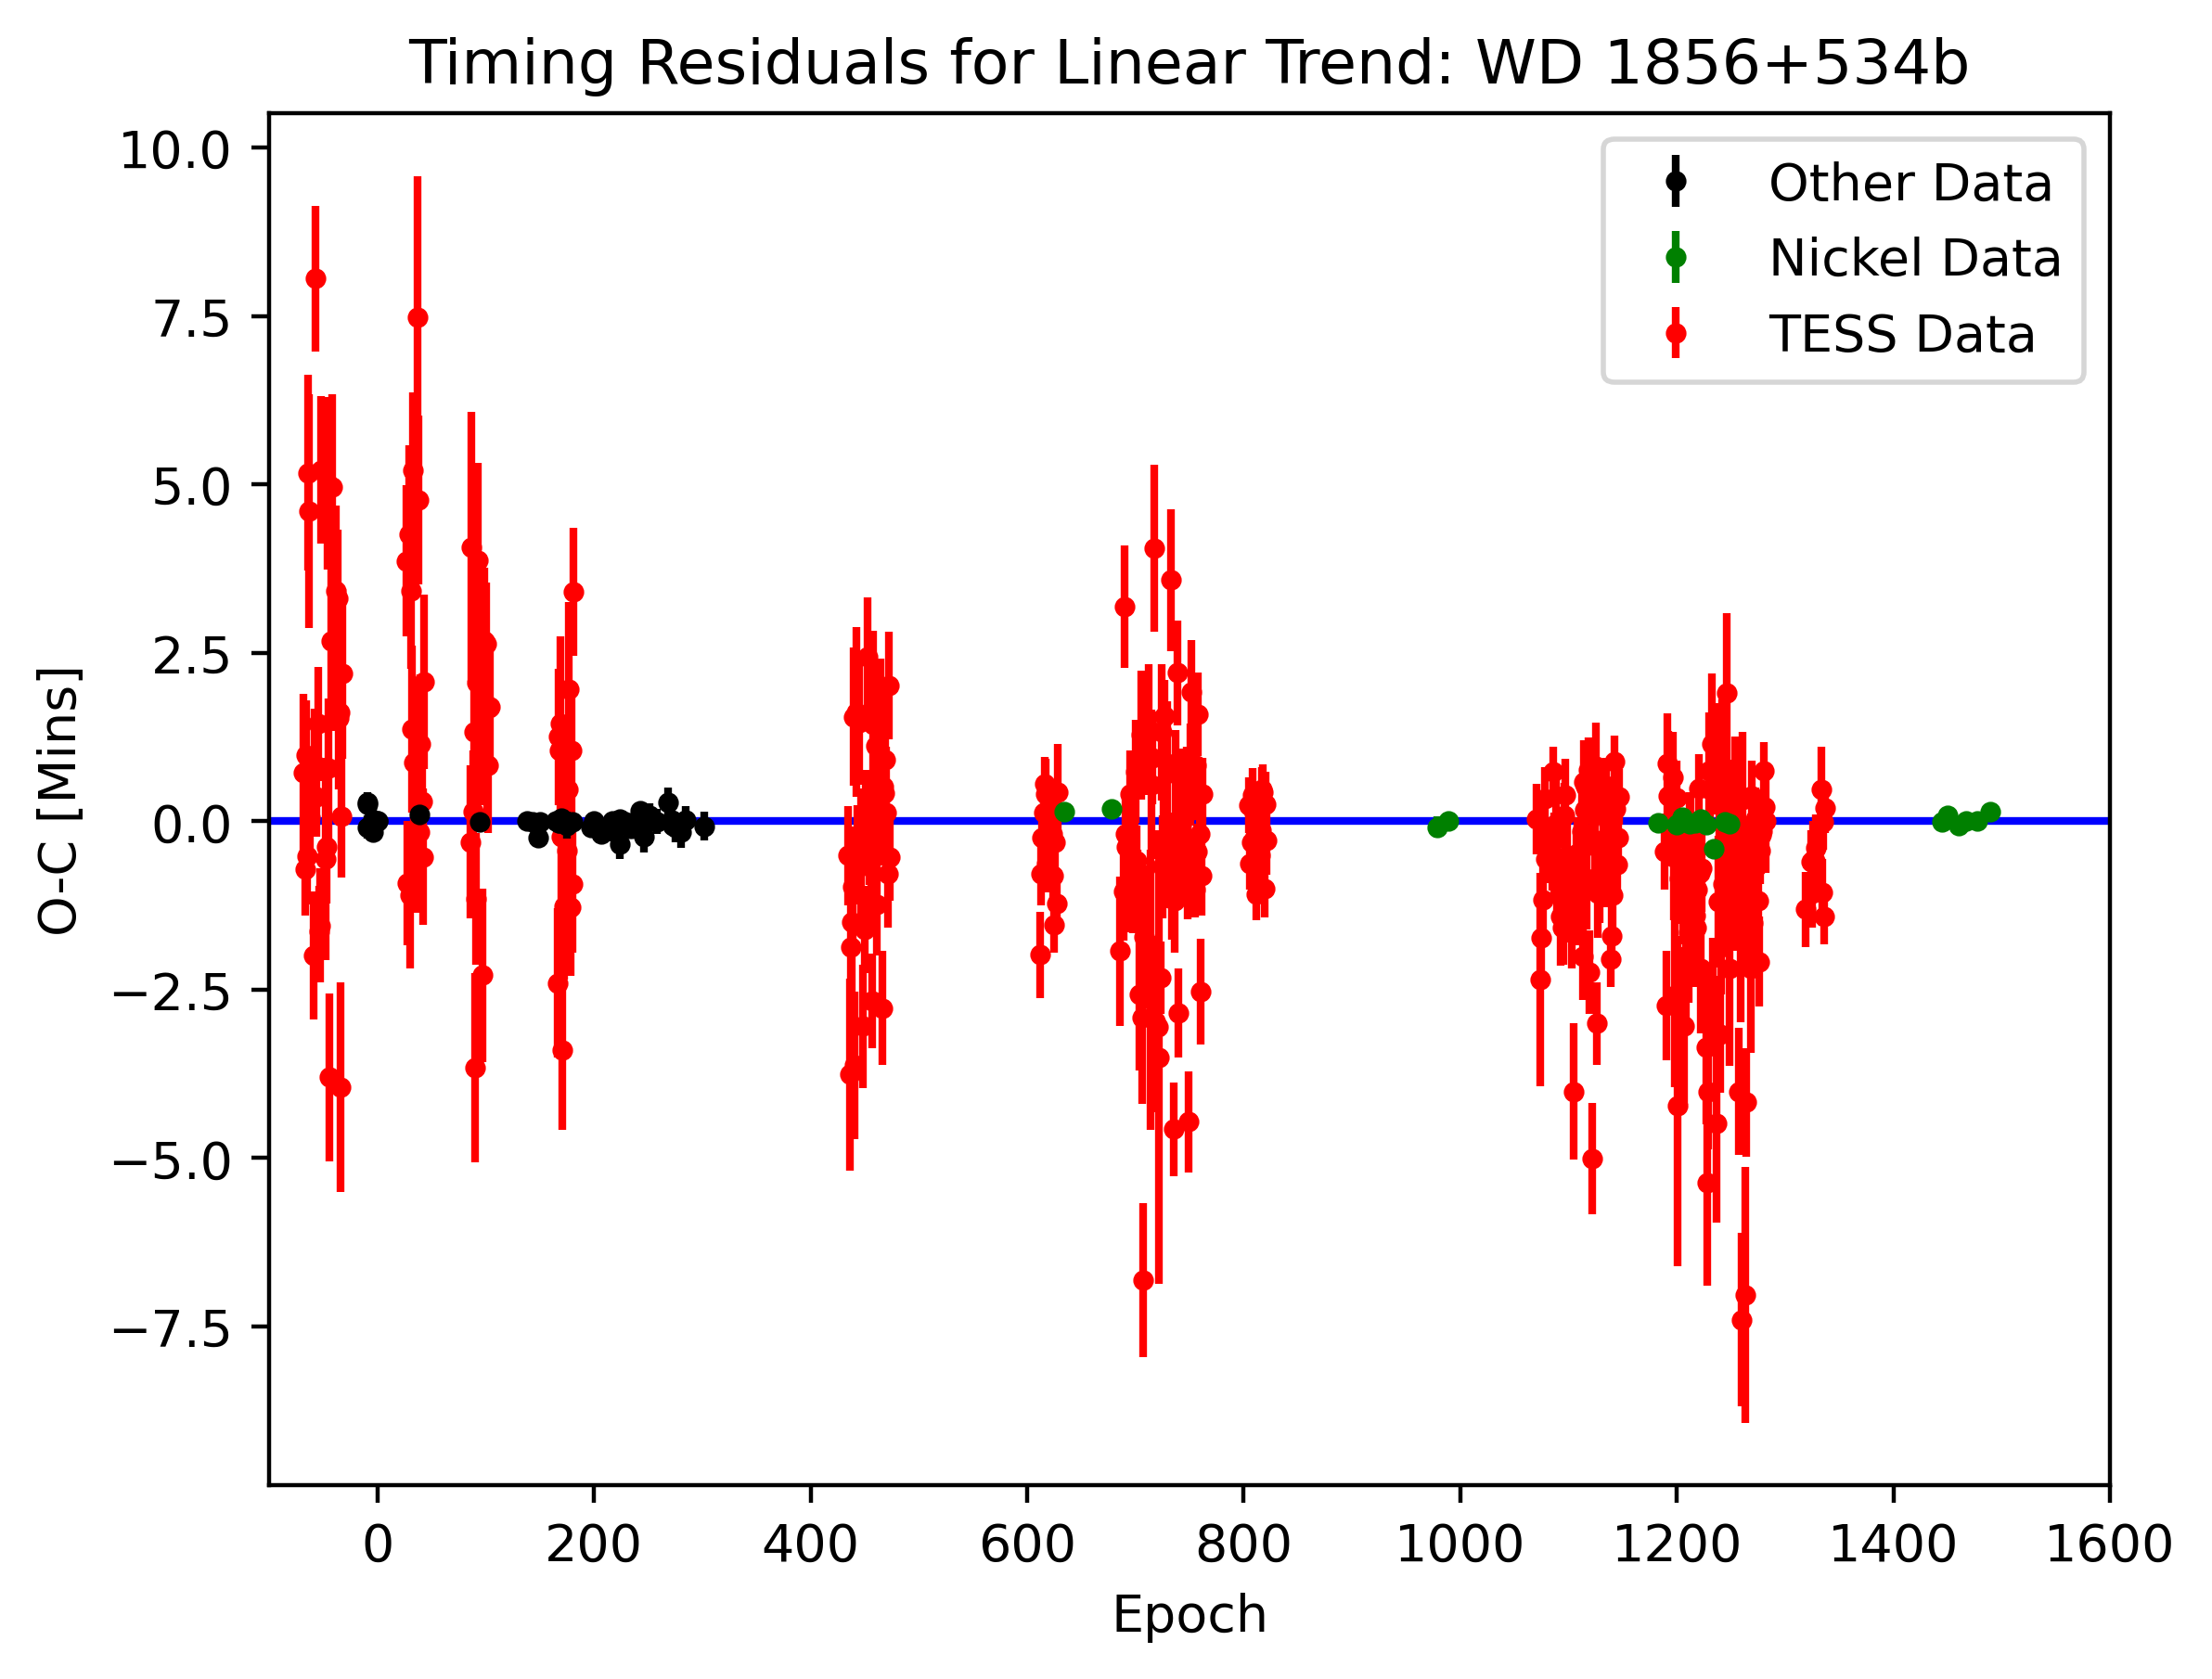

In [16]:
res = (t - trend) * 1440 # 1440 converts days to mins

plt.figure(dpi=400)
plt.errorbar(epoch[0:start_nickel],res[0:start_nickel],yerr=uncertainty[0:start_nickel]*1440,fmt='k.',capsize=0,label='Other Data',zorder=3)
plt.errorbar(epoch[start_nickel:start_tess],res[start_nickel:start_tess],yerr=uncertainty[start_nickel:start_tess]*1440,fmt='g.',capsize=0,label='Nickel Data',zorder=3)
plt.errorbar(epoch[start_tess:],res[start_tess:],yerr=uncertainty[start_tess:]*1440,fmt='r.',capsize=0,label='TESS Data',zorder=2)
plt.legend()
plt.xlim(-100,1600)
plt.hlines(y=0,xmin=-2500,xmax=2500,color='blue', zorder=1)
plt.ylabel('O-C [Mins]')
plt.xlabel('Epoch')
plt.title('Timing Residuals for Linear Trend: WD 1856+534b')
ax.minorticks_on()
plt.legend(loc='best')

In [17]:
def chi_squared_reduced(data, model, sigma, dof=None):
    """
    Calculate the reduced chi-squared value for a fit.

    If no dof is given, returns the chi-squared (non-reduced) value.

    Parameters
    ----------
    data : array_like
        The observed data.
    model : array_like
        The model data.
    sigma : array_like
        The uncertainty in the data.
    dof : int
        Degrees of freedom (len(data) - # of free parameters).
    """

    sq_residual = (data - model)**2
    chi_sq = np.sum(sq_residual / sigma**2)
    if dof is None:
        return chi_sq
    else:
        nu = len(data) - dof
        return chi_sq / nu

I_data = t  # data
I_modeled = trend # model predictions
I_sigma = uncertainty # uncertainty in data

chisq = chi_squared_reduced(I_data, I_modeled, I_sigma)
print(f"chi-squared statistic = {chisq:1.2f}")

dof = 2 # number of free parameters
rechisq = chi_squared_reduced(I_data, I_modeled, I_sigma, dof)
print(f"reduced chi-squared = {rechisq:1.2f}")

chi-squared statistic = 1541.78
reduced chi-squared = 3.72


In [18]:
BIC = chisq + 2*np.log(len(I_data))
print(f"BIC = {BIC:1.2f}")

BIC = 1553.84
